# Задание: Многовидовая 3D-реконструкция  
**Цель:** Восстановить трёхмерное облако точек по трём проекциям с неизвестных ракурсов.

**Срок:** дедлайн в 23:30 20 февраля.

# Входные данные
Вам дан список из трёх проекций (`data.pth`), а также массив цветов точек для удобства визуализации (`rgbs.pth`). Как можно видеть, каждый ракурс содержит лишь часть точек в облаке, а вашей целью будет совместить все эти части, получив трёхмерное облако точек.

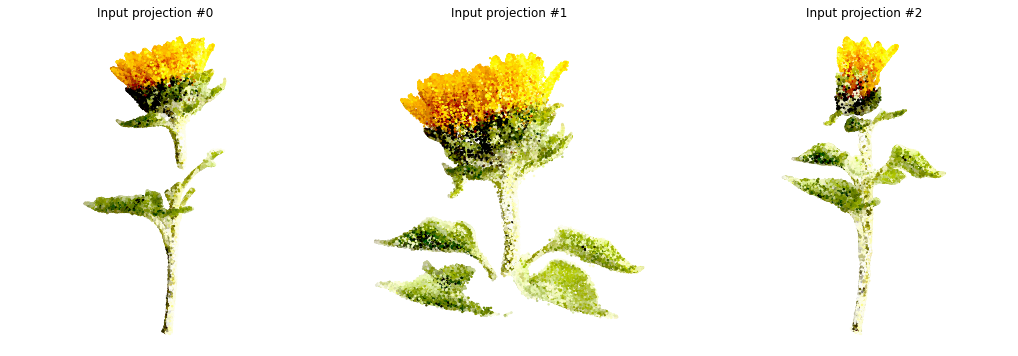

In [ ]:
import torch
import matplotlib.pylab as plt

projections = torch.load('data.pth')
rgbs = torch.load('rgbs.pth')

fig, axes = plt.subplots(1, 3, figsize=(18,6))
for n_camera, (d, ax) in enumerate(zip(projections, axes.flatten())):
    xs, ys = d['coordinates'].T
    indices = d['ids']
    ax.scatter(xs, ys, c=rgbs[indices], s=2.)
    ax.axis('equal')
    ax.axis('off')
    ax.set_title(f'Input projection #{n_camera}')

Каждая проекция получена с неизвестного ракурса с помощью пинхол камеры с фокусным расстоянием 50мм, матрица внутренних параметров имеет следующий вид:

```python
# параметры объектива указывают в миллиметрах, а размер сенсора соответствет ширине кадра плёнки
f = 50
sensor_size = 36
# по ним строим матрицу внутренних параметров
K = torch.tensor([
    [2 * f / sensor_size, 0.0, 0.0],
    [0.0, 2 * f / sensor_size, 0.0],
    [0.0,                 0.0, 1.0]
])
```

Каждая проекция задана словарём. Поле `ids` содержит массив с номерами точек в исходном облаке (по ним можно найти соответствия между парой ракурсов), а поле `coordinates` неоднородные координаты в плоскости сенсора. Каждая точка видна как минимум с двух ракурсов.

```python
projection_example = {
    'ids': torch.tensor([0, 1, 2], dtype=torch.int64),
    'coordinates': torch.tensor([[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]], dtype=torch.float32)
}
```

# Формат решения

Решение должно состоять из двух компонент:
1. Массив с реконструкцией исходного трёхмерного облака точек,
2. Отчёт в формате (PDF/Jupyter/Python/Markdown), с подробным описанием вашего метода и его реализацией.

## Облако точек

*Массив* будет использован для автоматизации проверки, но оценка за задание будет определяться в первую очередь на основе отчёта.
Ожидаемый формат массива - тензор размера $(N, 3)$.
```python
solution_example = torch.tensor([[0.1, 0.2, 0.0], [0.2, 0.3, 0.0], [0.3, 0.4, 0.0]], dtype=torch.float32)
```
Масштаб облака точек должен быть выбран исходя из предположения, что расстояние между первой и второй камерой равно *(условной)* единице.

## Отчёт

Вы свободны выбирать свой путь решения, но присланное решение не должно опираться на внешние реализации алгоритмов поиска фундаментальной матрицы, PnP, триангуляции и подобных. Иными словами, решение может использовать методы из библиотек torch`/`numpy, а более сложные алгоритмы должны быть реализованы внутри.

Для отладки и упрощения проверки рекомендуем включить в отчёт визуализации и тесты промежуточных шагов с пояснениями. Также полезной может оказаться визуализация облака точек:
```python
import open3d as o3d
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([pcd])
```